# 01 — Train Baseline
Patient-level split, no leakage, test touched once at end.

In [1]:
import os, json, random, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available() else 'cpu'))

PROJECT_ROOT = Path('/Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence')
DB_PATH = Path('/Users/ayoub/work/MS-DS_ML_Projects/IOT/mitbih_database')
OUT = PROJECT_ROOT / 'results' / 'baseline'
OUT.mkdir(parents=True, exist_ok=True)
WEIGHTS = PROJECT_ROOT / 'baseline' / 'weights' / 'baseline_best.pt'
print('Device:', device)

Device: mps


## Architecture choice
Using a compact 1D-CNN for ECG waveform classification to balance accuracy and embedded inference cost.

In [2]:
AAMI_MAP = {'N':0,'L':0,'R':0,'e':0,'j':0,'A':1,'a':1,'J':1,'S':1,'V':2,'E':2,'F':3,'/':4,'f':4,'Q':4}
LABELS = ['N','S','V','F','Q']
FS, WINDOW = 360.0, 180
HALF = WINDOW // 2

def bandpass(x, low=0.5, high=40, fs=FS, order=1):
    nyq = 0.5*fs
    b,a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b,a,x)

def minmax(x):
    x = x.astype(np.float32)
    mn,mx = x.min(), x.max()
    return np.zeros_like(x) if mx<=mn else (x-mn)/(mx-mn)

def pick_signal_column(df):
    cols = [str(c).replace("'", '').strip() for c in df.columns]
    df.columns = cols
    for cand in ['MLII', 'II', 'V5', 'V1']:
        if cand in cols:
            return cand
    numeric_cols = [c for c in cols if np.issubdtype(df[c].dtype, np.number)]
    if not numeric_cols:
        raise ValueError('No numeric signal column found')
    bad = {'sample', 'samples', 'time', 'index'}
    filtered = [c for c in numeric_cols if c.lower() not in bad]
    return filtered[0] if filtered else numeric_cols[0]

def load_record(rid):
    sig = pd.read_csv(DB_PATH / f'{rid}.csv')
    lead = pick_signal_column(sig)
    x = sig[lead].values.astype(np.float32)
    ann = pd.read_csv(DB_PATH / f'{rid}annotations.txt', sep=r'\s+', skiprows=1, header=None, engine='python', on_bad_lines='skip')
    return x, ann.iloc[:,1].astype(int).values, ann.iloc[:,2].astype(str).values

def extract_beats(records):
    X, R, y = [], [], []
    for rid in records:
        x,samps,syms = load_record(rid)
        x = bandpass(x)
        samps = samps.astype(np.int64)
        for i, (r,s) in enumerate(zip(samps, syms)):
            if s not in AAMI_MAP:
                continue
            st,en = int(r)-HALF, int(r)+HALF
            if st<0 or en>len(x) or (en-st)!=WINDOW:
                continue

            prev_rr = float(samps[i] - samps[i-1]) if i > 0 else float(HALF)
            next_rr = float(samps[i+1] - samps[i]) if i < len(samps)-1 else float(HALF)
            local_hr = 60.0 * FS / max(prev_rr, 1.0)

            rr_feat = np.array([
                np.clip(prev_rr / FS, 0.0, 2.0),
                np.clip(next_rr / FS, 0.0, 2.0),
                np.clip(local_hr / 220.0, 0.0, 1.0),
            ], dtype=np.float32)

            X.append(minmax(x[st:en]))
            R.append(rr_feat)
            y.append(AAMI_MAP[s])
    return np.array(X, dtype=np.float32), np.array(R, dtype=np.float32), np.array(y, dtype=np.int64)

def print_dist(name, y):
    cnt = {k:int(v) for k,v in zip(*np.unique(y, return_counts=True))}
    total = max(len(y), 1)
    print(f'\n{name} (n={len(y)}):')
    for c in range(5):
        n = cnt.get(c, 0)
        print(f'  {LABELS[c]}: {n:6d} ({100*n/total:5.2f}%)')

In [3]:
records = sorted([p.stem for p in DB_PATH.glob('*.csv')])

# Patient-level split search with strict S/F feasibility gate
record_ann_counts = {}
for rid in records:
    ann = pd.read_csv(DB_PATH / f'{rid}annotations.txt', sep=r'\s+', skiprows=1, header=None, engine='python', on_bad_lines='skip')
    syms = ann.iloc[:,2].astype(str).values
    cnt = np.zeros(5, dtype=int)
    for s in syms:
        if s in AAMI_MAP:
            cnt[AAMI_MAP[s]] += 1
    record_ann_counts[rid] = cnt

def agg_counts(rids):
    out = np.zeros(5, dtype=int)
    for r in rids:
        out += record_ann_counts[r]
    return out

def safe_split(indices, test_size, strat_labels, seed):
    try:
        return train_test_split(indices, test_size=test_size, random_state=seed, stratify=strat_labels)
    except Exception:
        return train_test_split(indices, test_size=test_size, random_state=seed, stratify=None)

def dist_shift(trc, vac, tec):
    trp = trc / max(trc.sum(), 1)
    vap = vac / max(vac.sum(), 1)
    tep = tec / max(tec.sum(), 1)
    return float(np.sum(np.abs(vap - trp)) + np.sum(np.abs(tep - trp)))

dominant = np.array([int(np.argmax(record_ann_counts[r])) for r in records])
idx_all = np.arange(len(records))

# strict feasibility requirements (annotation-level pre-check)
TRAIN_F_FLOOR = 500
STRICT_VAL_S_FLOOR = 60
STRICT_VAL_F_FLOOR = 20
STRICT_VAL_Q_FLOOR = 20
STRICT_TEST_S_FLOOR = 60
STRICT_TEST_F_FLOOR = 20
STRICT_TEST_Q_FLOOR = 20

# relaxed fallback feasibility (still meaningful)
RELAXED_VAL_S_FLOOR = 20
RELAXED_VAL_F_FLOOR = 5
RELAXED_VAL_Q_FLOOR = 5
RELAXED_TEST_S_FLOOR = 20
RELAXED_TEST_F_FLOOR = 5
RELAXED_TEST_Q_FLOOR = 5

best_strict = None
best_relaxed = None
best_train_f = None

SEARCH_TRIALS = 30000
for seed in range(SEED, SEED + SEARCH_TRIALS):
    tr_idx, tmp_idx = safe_split(idx_all, 0.30, dominant, seed)
    va_rel, te_rel = safe_split(np.arange(len(tmp_idx)), 0.50, dominant[tmp_idx], seed)
    va_idx, te_idx = tmp_idx[va_rel], tmp_idx[te_rel]

    tr_recs = [records[i] for i in tr_idx]
    va_recs = [records[i] for i in va_idx]
    te_recs = [records[i] for i in te_idx]

    trc = agg_counts(tr_recs)
    vac = agg_counts(va_recs)
    tec = agg_counts(te_recs)

    rank_key = (
        -dist_shift(trc, vac, tec),
        int(vac[1]) + int(tec[1]),
        int(vac[3]) + int(tec[3]),
        int(vac[4]) + int(tec[4]),
        int(trc[3]),
    )
    entry = (tr_recs, va_recs, te_recs, trc, vac, tec, seed, rank_key)

    if best_train_f is None or rank_key > best_train_f[-1]:
        best_train_f = entry

    strict_ok = (
        int(trc[3]) >= TRAIN_F_FLOOR and
        int(vac[1]) >= STRICT_VAL_S_FLOOR and int(vac[3]) >= STRICT_VAL_F_FLOOR and int(vac[4]) >= STRICT_VAL_Q_FLOOR and
        int(tec[1]) >= STRICT_TEST_S_FLOOR and int(tec[3]) >= STRICT_TEST_F_FLOOR and int(tec[4]) >= STRICT_TEST_Q_FLOOR
    )
    if strict_ok and (best_strict is None or rank_key > best_strict[-1]):
        best_strict = entry

    relaxed_ok = (
        int(trc[3]) >= TRAIN_F_FLOOR and
        int(vac[1]) >= RELAXED_VAL_S_FLOOR and int(vac[3]) >= RELAXED_VAL_F_FLOOR and int(vac[4]) >= RELAXED_VAL_Q_FLOOR and
        int(tec[1]) >= RELAXED_TEST_S_FLOOR and int(tec[3]) >= RELAXED_TEST_F_FLOOR and int(tec[4]) >= RELAXED_TEST_Q_FLOOR
    )
    if relaxed_ok and (best_relaxed is None or rank_key > best_relaxed[-1]):
        best_relaxed = entry

if best_strict is not None:
    best = best_strict
    print('Selected split tier: STRICT feasibility tier.')
elif best_relaxed is not None:
    best = best_relaxed
    print('Selected split tier: RELAXED feasibility tier.')
else:
    best = best_train_f
    trc, vac, tec = best[3], best[4], best[5]
    raise RuntimeError(
        'No viable patient-level split found with sufficient S/F/Q support after extensive search. '
        f"Best found ann counts -> Train F={int(trc[3])}, Val (S/F/Q)=({int(vac[1])}/{int(vac[3])}/{int(vac[4])}), Test (S/F/Q)=({int(tec[1])}/{int(tec[3])}/{int(tec[4])}). "
        'Training is aborted intentionally to avoid wasted runs with dead minority classes.'
    )

train_records, val_records, test_records, trc, vac, tec, split_seed, _ = best
print('Selected split seed:', split_seed)
print('Annotation counts (N,S,V,F,Q):')
print('Train:', trc.tolist(), '| Val:', vac.tolist(), '| Test:', tec.tolist())

X_train_raw, R_train_raw, y_train_raw = extract_beats(train_records)
X_val, R_val, y_val = extract_beats(val_records)
X_test, R_test, y_test = extract_beats(test_records)
print('Raw shapes:', X_train_raw.shape, X_val.shape, X_test.shape)
print('RR shapes :', R_train_raw.shape, R_val.shape, R_test.shape)
print_dist('TRAIN raw', y_train_raw)
print_dist('VAL', y_val)
print_dist('TEST', y_test)

# Train-only targeted augmentation for minority classes S (1) and F (3)
S_TARGET = 12000
F_TARGET = 9000
NOISE_STD = 0.015
SCALE_RANGE = (0.90, 1.10)
MAX_SHIFT = 8

def augment_to_target(X, R, y, class_id, target_count):
    rng = np.random.default_rng(SEED + class_id)
    mask = (y == class_id)
    Xc = X[mask]
    Rc = R[mask]
    if len(Xc) == 0 or len(Xc) >= target_count:
        return X, R, y

    n_extra = target_count - len(Xc)
    idx = rng.integers(0, len(Xc), size=n_extra)
    base = Xc[idx]
    rr_base = Rc[idx]

    scale = rng.uniform(*SCALE_RANGE, size=(n_extra, 1)).astype(np.float32)
    noise = rng.normal(0, NOISE_STD, size=base.shape).astype(np.float32)
    shift = rng.integers(-MAX_SHIFT, MAX_SHIFT + 1, size=n_extra)

    aug = np.clip(base * scale + noise, 0.0, 1.0)
    aug = np.array([np.roll(aug[i], int(shift[i])) for i in range(n_extra)], dtype=np.float32)

    rr_noise = rng.normal(0.0, 0.02, size=rr_base.shape).astype(np.float32)
    rr_aug = np.clip(rr_base + rr_noise, 0.0, 2.0)

    X_out = np.concatenate([X, aug], axis=0)
    R_out = np.concatenate([R, rr_aug], axis=0)
    y_out = np.concatenate([y, np.full(n_extra, class_id, dtype=np.int64)], axis=0)
    return X_out, R_out, y_out

X_train_aug, R_train_aug, y_train_aug = X_train_raw.copy(), R_train_raw.copy(), y_train_raw.copy()
X_train_aug, R_train_aug, y_train_aug = augment_to_target(X_train_aug, R_train_aug, y_train_aug, class_id=1, target_count=S_TARGET)
X_train_aug, R_train_aug, y_train_aug = augment_to_target(X_train_aug, R_train_aug, y_train_aug, class_id=3, target_count=F_TARGET)

perm = np.random.default_rng(SEED).permutation(len(X_train_aug))
X_train, R_train, y_train = X_train_aug[perm], R_train_aug[perm], y_train_aug[perm]

print('\nAugmented train shape:', X_train.shape)
print('Augmented RR shape   :', R_train.shape)
print_dist('TRAIN aug', y_train)

Selected split tier: STRICT feasibility tier.
Selected split seed: 25789
Annotation counts (N,S,V,F,Q):
Train: [61412, 2339, 5208, 758, 4152] | Val: [15116, 222, 1109, 25, 2084] | Test: [14103, 220, 919, 20, 1807]
Raw shapes: (73849, 180) (18551, 180) (17068, 180)
RR shapes : (73849, 3) (18551, 3) (17068, 3)

TRAIN raw (n=73849):
  N:  61394 (83.13%)
  S:   2339 ( 3.17%)
  V:   5208 ( 7.05%)
  F:    757 ( 1.03%)
  Q:   4151 ( 5.62%)

VAL (n=18551):
  N:  15112 (81.46%)
  S:    222 ( 1.20%)
  V:   1108 ( 5.97%)
  F:     25 ( 0.13%)
  Q:   2084 (11.23%)

TEST (n=17068):
  N:  14102 (82.62%)
  S:    220 ( 1.29%)
  V:    919 ( 5.38%)
  F:     20 ( 0.12%)
  Q:   1807 (10.59%)

Augmented train shape: (91753, 180)
Augmented RR shape   : (91753, 3)

TRAIN aug (n=91753):
  N:  61394 (66.91%)
  S:  12000 (13.08%)
  V:   5208 ( 5.68%)
  F:   9000 ( 9.81%)
  Q:   4151 ( 4.52%)


In [4]:
class TripleHeadECGCNN(nn.Module):
    def __init__(self, n_classes=5, dropout=0.35, rr_dim=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 32, 5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, 5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 64, 3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, 3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.rr_mlp = nn.Sequential(
            nn.Linear(rr_dim, 16), nn.ReLU(),
            nn.Linear(16, 16), nn.ReLU(),
        )
        self.dropout = nn.Dropout(dropout)
        self.main_head = nn.Linear(128 + 16, n_classes)
        self.s_head = nn.Linear(128 + 16, 1)
        self.f_head = nn.Linear(128 + 16, 1)

    def forward(self, x, rr):
        z = self.features(x).squeeze(-1)
        r = self.rr_mlp(rr)
        z = torch.cat([z, r], dim=1)
        z = self.dropout(z)
        main_logits = self.main_head(z)
        s_logit = self.s_head(z).squeeze(-1)
        f_logit = self.f_head(z).squeeze(-1)
        return main_logits, s_logit, f_logit

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

xtr = torch.tensor(X_train).unsqueeze(1)
rtr = torch.tensor(R_train)
ytr = torch.tensor(y_train)
xva = torch.tensor(X_val).unsqueeze(1)
rva = torch.tensor(R_val)
yva = torch.tensor(y_val)
xte = torch.tensor(X_test).unsqueeze(1)
rte = torch.tensor(R_test)
yte = torch.tensor(y_test)

counts = np.bincount(y_train, minlength=5).astype(np.float32)
inv = 1.0 / (counts + 1e-6)
alpha = np.clip(inv / inv.mean(), 1.0, 8.0)
alpha[1] = min(alpha[1] * 1.8, 12.0)
alpha[3] = min(alpha[3] * 3.0, 18.0)
alpha_t = torch.tensor(alpha, dtype=torch.float32, device=device)

sample_w = (inv[y_train] / inv[y_train].mean()).astype(np.float64)
sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.tensor(sample_w, dtype=torch.double),
    num_samples=len(sample_w),
    replacement=True,
)

train_loader = DataLoader(TensorDataset(xtr, rtr, ytr), batch_size=512, sampler=sampler)
val_loader = DataLoader(TensorDataset(xva, rva, yva), batch_size=512, shuffle=False)
test_loader = DataLoader(TensorDataset(xte, rte, yte), batch_size=512, shuffle=False)

s_pos = float((y_train == 1).sum())
f_pos = float((y_train == 3).sum())
n_total = float(len(y_train))
s_pos_weight = torch.tensor(float(np.clip((n_total - s_pos) / max(s_pos, 1), 1.0, 30.0)), dtype=torch.float32, device=device)
f_pos_weight = torch.tensor(float(np.clip((n_total - f_pos) / max(f_pos, 1), 1.0, 80.0)), dtype=torch.float32, device=device)

model = TripleHeadECGCNN().to(device)
criterion_main = FocalLoss(gamma=2.0, alpha=alpha_t)
criterion_s = nn.BCEWithLogitsLoss(pos_weight=s_pos_weight)
criterion_f = nn.BCEWithLogitsLoss(pos_weight=f_pos_weight)

AUX_S_WEIGHT = 0.45
AUX_F_WEIGHT = 1.75

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=8)

print('Focal alpha:', {LABELS[i]: round(float(alpha[i]), 3) for i in range(5)})
print(f'S pos_weight={float(s_pos_weight):.2f} | F pos_weight={float(f_pos_weight):.2f}')

Focal alpha: {'N': 1.0, 'S': 1.8, 'V': 1.492, 'F': 3.0, 'Q': 1.871}
S pos_weight=6.65 | F pos_weight=9.19


In [5]:
EPOCHS = 18
PATIENCE = 6
GRAD_CLIP = 2.0
print(f'Training config -> EPOCHS={EPOCHS}, PATIENCE={PATIENCE}, GRAD_CLIP={GRAD_CLIP}')

Training config -> EPOCHS=18, PATIENCE=6, GRAD_CLIP=2.0


In [6]:
history = []
best_f1 = -1.0
best_state = None
wait = 0

cur_aux_s = float(AUX_S_WEIGHT)
cur_aux_f = float(AUX_F_WEIGHT)
sf_stall = 0
retry_used = False

def sf_dead(vpc):
    return float(vpc[1]) <= 1e-6 and float(vpc[3]) <= 1e-6

def hard_negative_f_loss(f_logit, y_true, pos_weight, neg_mult=8, min_hard=64):
    f_tgt = (y_true == 3).float()
    loss_all = nn.functional.binary_cross_entropy_with_logits(
        f_logit, f_tgt, reduction='none', pos_weight=pos_weight
    )
    pos_mask = f_tgt > 0.5
    neg_mask = ~pos_mask

    pos_losses = loss_all[pos_mask]
    neg_losses = loss_all[neg_mask]
    n_pos = int(pos_mask.sum().item())

    if n_pos > 0 and neg_losses.numel() > 0:
        k = min(int(neg_losses.numel()), max(min_hard, neg_mult * n_pos))
        hard_neg, _ = torch.topk(neg_losses, k)
        return (pos_losses.sum() + hard_neg.sum()) / max(n_pos + k, 1)

    return loss_all.mean()

try:
    for epoch in range(1, EPOCHS + 1):
        model.train(); tr_loss=0.0; n=0
        for bx, br, by in train_loader:
            bx, br, by = bx.to(device), br.to(device), by.to(device)
            optimizer.zero_grad()
            main_logits, s_logit, f_logit = model(bx, br)

            loss_main = criterion_main(main_logits, by)
            loss_s = criterion_s(s_logit, (by == 1).float())
            loss_f = hard_negative_f_loss(f_logit, by, f_pos_weight, neg_mult=10, min_hard=96)
            loss = loss_main + cur_aux_s * loss_s + cur_aux_f * loss_f

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            tr_loss += loss.item()*bx.size(0); n += bx.size(0)
        tr_loss /= max(n,1)

        model.eval(); preds=[]; targs=[]; vloss=0.0; nv=0
        with torch.no_grad():
            for bx, br, by in val_loader:
                bx, br, by = bx.to(device), br.to(device), by.to(device)
                main_logits, s_logit, f_logit = model(bx, br)

                loss_main = criterion_main(main_logits, by)
                loss_s = criterion_s(s_logit, (by == 1).float())
                loss_f = hard_negative_f_loss(f_logit, by, f_pos_weight, neg_mult=8, min_hard=64)
                loss = loss_main + cur_aux_s * loss_s + cur_aux_f * loss_f

                adj = main_logits.clone()
                adj[:, 1] += 0.7 * torch.sigmoid(s_logit)
                adj[:, 3] += 1.0 * torch.sigmoid(f_logit)

                vloss += loss.item()*bx.size(0); nv += bx.size(0)
                preds.extend(adj.argmax(1).cpu().numpy()); targs.extend(by.cpu().numpy())

        vloss /= max(nv,1)
        vacc = accuracy_score(targs, preds)
        vf1 = f1_score(targs, preds, average='macro', zero_division=0)
        vpc = f1_score(targs, preds, average=None, labels=np.arange(5), zero_division=0)
        history.append({'epoch':epoch,'train_loss':float(tr_loss),'val_loss':float(vloss),'val_accuracy':float(vacc),'val_macro_f1':float(vf1),'val_s_f1':float(vpc[1]),'val_f_f1':float(vpc[3]),'aux_s':cur_aux_s,'aux_f':cur_aux_f})
        print(f"E{epoch:02d} train_loss={tr_loss:.4f} val_loss={vloss:.4f} val_acc={vacc:.4f} val_f1={vf1:.4f} S={vpc[1]:.4f} F={vpc[3]:.4f} auxS={cur_aux_s:.2f} auxF={cur_aux_f:.2f}")

        if epoch >= 3 and sf_dead(vpc):
            sf_stall += 1
        else:
            sf_stall = 0

        if sf_stall >= 2:
            if not retry_used:
                retry_used = True
                cur_aux_s = min(cur_aux_s + 0.15, 0.60)
                cur_aux_f = min(cur_aux_f + 0.55, 2.40)
                sf_stall = 0
                print(f"Adaptive retry activated -> aux weights updated to S={cur_aux_s:.2f}, F={cur_aux_f:.2f}")
            else:
                print('S/F remained dead after retry -> early stop to prevent wasted training.')
                break

        scheduler.step()
        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print('Early stopping')
                break

except KeyboardInterrupt:
    print('Manual interruption detected. Preserving best checkpoint so far...')

if best_state is None:
    raise RuntimeError('No checkpoint captured; training ended before a valid epoch result.')

model.load_state_dict(best_state)
torch.save(best_state, WEIGHTS)
print('Saved checkpoint:', WEIGHTS)

# ===== Stage-2 dedicated F specialist (binary F-vs-rest) =====
class FSpecialistMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32), nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

def collect_meta_features(x_tensor, r_tensor, y_tensor, batch_size=1024):
    ds = TensorDataset(x_tensor, r_tensor, y_tensor)
    ld = DataLoader(ds, batch_size=batch_size, shuffle=False)
    feats, labels = [], []
    model.eval()
    with torch.no_grad():
        for bx, br, by in ld:
            bx = bx.to(device)
            br = br.to(device)
            main_logits, s_logit, f_logit = model(bx, br)
            main_np = main_logits.cpu().numpy()
            s_np = torch.sigmoid(s_logit).cpu().numpy()[:, None]
            f_np = torch.sigmoid(f_logit).cpu().numpy()[:, None]
            rr_np = br.cpu().numpy()
            meta = np.concatenate([main_np, s_np, f_np, rr_np], axis=1)
            feats.append(meta)
            labels.append((by.numpy() == 3).astype(np.float32))
    return np.concatenate(feats, axis=0).astype(np.float32), np.concatenate(labels, axis=0).astype(np.float32)

tr_meta, tr_fy = collect_meta_features(xtr, rtr, ytr)
va_meta, va_fy = collect_meta_features(xva, rva, yva)

pos_idx = np.where(tr_fy == 1.0)[0]
neg_idx = np.where(tr_fy == 0.0)[0]
if len(pos_idx) == 0:
    raise RuntimeError('No positive F samples available for specialist training.')

neg_rank = np.argsort(-tr_meta[neg_idx, 6])
max_neg = min(len(neg_idx), max(2000, 20 * len(pos_idx)))
hard_neg_idx = neg_idx[neg_rank[:max_neg]]
sel_idx = np.concatenate([pos_idx, hard_neg_idx])

spec_x = tr_meta[sel_idx]
spec_y = tr_fy[sel_idx]

spec_inv = np.where(spec_y > 0.5, 1.0 / max(spec_y.sum(), 1.0), 1.0 / max((len(spec_y) - spec_y.sum()), 1.0))
spec_sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.tensor(spec_inv, dtype=torch.double),
    num_samples=len(spec_y),
    replacement=True,
)

spec_train_loader = DataLoader(
    TensorDataset(torch.tensor(spec_x), torch.tensor(spec_y)),
    batch_size=256,
    sampler=spec_sampler,
)

f_specialist = FSpecialistMLP(in_dim=tr_meta.shape[1]).to(device)
spec_pos = float(spec_y.sum())
spec_neg = float(len(spec_y) - spec_pos)
spec_pos_weight = torch.tensor(float(np.clip(spec_neg / max(spec_pos, 1.0), 1.0, 50.0)), dtype=torch.float32, device=device)
spec_criterion = nn.BCEWithLogitsLoss(pos_weight=spec_pos_weight)
spec_optimizer = torch.optim.AdamW(f_specialist.parameters(), lr=5e-4, weight_decay=1e-4)

x_val_spec = torch.tensor(va_meta, dtype=torch.float32).to(device)
y_val_spec = torch.tensor(va_fy, dtype=torch.float32).cpu().numpy()

best_spec_f1 = -1.0
best_spec_state = None
spec_wait = 0
SPEC_EPOCHS = 12
SPEC_PATIENCE = 4

for epoch in range(1, SPEC_EPOCHS + 1):
    f_specialist.train()
    for bx, by in spec_train_loader:
        bx = bx.to(device)
        by = by.to(device)
        spec_optimizer.zero_grad()
        logit = f_specialist(bx)
        loss = spec_criterion(logit, by)
        loss.backward()
        nn.utils.clip_grad_norm_(f_specialist.parameters(), 2.0)
        spec_optimizer.step()

    f_specialist.eval()
    with torch.no_grad():
        val_prob = torch.sigmoid(f_specialist(x_val_spec)).cpu().numpy()
    val_pred = (val_prob >= 0.5).astype(np.int64)
    val_bin_f1 = f1_score(y_val_spec.astype(np.int64), val_pred, zero_division=0)
    print(f"Specialist E{epoch:02d} val_f1(F-vs-rest)={val_bin_f1:.4f}")

    if val_bin_f1 > best_spec_f1:
        best_spec_f1 = float(val_bin_f1)
        best_spec_state = {k: v.detach().cpu().clone() for k, v in f_specialist.state_dict().items()}
        spec_wait = 0
    else:
        spec_wait += 1
        if spec_wait >= SPEC_PATIENCE:
            print('Specialist early stopping')
            break

if best_spec_state is None:
    raise RuntimeError('Specialist training failed to capture a valid checkpoint.')

f_specialist.load_state_dict(best_spec_state)
f_specialist.eval()
print(f'Specialist ready. Best val F1 (F-vs-rest): {best_spec_f1:.4f}')

E01 train_loss=2.3541 val_loss=2.0025 val_acc=0.3376 val_f1=0.2686 S=0.0337 F=0.0068 auxS=0.45 auxF=1.75
E02 train_loss=1.3525 val_loss=1.5719 val_acc=0.4896 val_f1=0.3129 S=0.0451 F=0.0047 auxS=0.45 auxF=1.75
E03 train_loss=1.0277 val_loss=1.4522 val_acc=0.5974 val_f1=0.3653 S=0.0650 F=0.0031 auxS=0.45 auxF=1.75
E04 train_loss=0.8379 val_loss=1.2545 val_acc=0.7215 val_f1=0.4212 S=0.0603 F=0.0000 auxS=0.45 auxF=1.75
E05 train_loss=0.7106 val_loss=1.2050 val_acc=0.7476 val_f1=0.4523 S=0.0737 F=0.0115 auxS=0.45 auxF=1.75
E06 train_loss=0.6297 val_loss=1.1088 val_acc=0.7730 val_f1=0.4555 S=0.0674 F=0.0000 auxS=0.45 auxF=1.75
E07 train_loss=0.5867 val_loss=1.1337 val_acc=0.7715 val_f1=0.4643 S=0.0694 F=0.0157 auxS=0.45 auxF=1.75
E08 train_loss=0.5569 val_loss=1.1511 val_acc=0.7715 val_f1=0.4624 S=0.0751 F=0.0000 auxS=0.45 auxF=1.75
E09 train_loss=0.5607 val_loss=1.1494 val_acc=0.7703 val_f1=0.4625 S=0.0773 F=0.0000 auxS=0.45 auxF=1.75
E10 train_loss=0.5522 val_loss=1.1455 val_acc=0.7698 va

In [7]:
# Test set touched once, here at the end
model.eval()
f_specialist.eval()

val_main, val_s, val_f, val_rr, val_targets = [], [], [], [], []
test_main, test_s, test_f, test_rr, test_targets = [], [], [], [], []

with torch.no_grad():
    for bx, br, by in val_loader:
        main_logits, s_logit, f_logit = model(bx.to(device), br.to(device))
        val_main.append(main_logits.cpu().numpy())
        val_s.append(torch.sigmoid(s_logit).cpu().numpy())
        val_f.append(torch.sigmoid(f_logit).cpu().numpy())
        val_rr.append(br.numpy())
        val_targets.append(by.numpy())

    t0 = time.perf_counter()
    for bx, br, by in test_loader:
        main_logits, s_logit, f_logit = model(bx.to(device), br.to(device))
        test_main.append(main_logits.cpu().numpy())
        test_s.append(torch.sigmoid(s_logit).cpu().numpy())
        test_f.append(torch.sigmoid(f_logit).cpu().numpy())
        test_rr.append(br.numpy())
        test_targets.append(by.numpy())
    t1 = time.perf_counter()

val_main = np.concatenate(val_main, axis=0)
val_s = np.concatenate(val_s, axis=0)
val_f = np.concatenate(val_f, axis=0)
val_rr = np.concatenate(val_rr, axis=0)
val_targets = np.concatenate(val_targets, axis=0)

test_main = np.concatenate(test_main, axis=0)
test_s = np.concatenate(test_s, axis=0)
test_f = np.concatenate(test_f, axis=0)
test_rr = np.concatenate(test_rr, axis=0)
test_targets = np.concatenate(test_targets, axis=0)

val_meta = np.concatenate([val_main, val_s[:, None], val_f[:, None], val_rr], axis=1).astype(np.float32)
test_meta = np.concatenate([test_main, test_s[:, None], test_f[:, None], test_rr], axis=1).astype(np.float32)

with torch.no_grad():
    val_spec_prob = torch.sigmoid(f_specialist(torch.tensor(val_meta, dtype=torch.float32).to(device))).cpu().numpy()
    test_spec_prob = torch.sigmoid(f_specialist(torch.tensor(test_meta, dtype=torch.float32).to(device))).cpu().numpy()

def calibrated_predict(main_logits, s_prob, f_prob, f_spec_prob, cfg):
    adj = main_logits.copy()
    adj[:, 0] -= cfg['penalty_n']
    adj[:, 1] += cfg['bias_s'] + cfg['boost_s'] * np.maximum(s_prob - cfg['tau_s'], 0.0)
    adj[:, 3] += cfg['bias_f'] + cfg['boost_f'] * np.maximum(f_prob - cfg['tau_f'], 0.0)
    adj[:, 3] += cfg['spec_boost'] * np.maximum(f_spec_prob - cfg['f_spec_tau'], 0.0)

    pred = adj.argmax(axis=1)

    top = np.max(adj, axis=1)
    f_margin = top - adj[:, 3]
    candidate = np.isin(pred, [0, 1, 2, 4])
    specialist_hit = candidate & (f_spec_prob >= cfg['f_spec_force_tau']) & (f_margin <= cfg['f_stage_margin'])
    pred[specialist_hit] = 3
    return pred

base_cfg = {
    'bias_s': 0.0,
    'bias_f': 0.0,
    'penalty_n': 0.0,
    'boost_s': 0.0,
    'boost_f': 0.0,
    'tau_s': 1.0,
    'tau_f': 1.0,
    'spec_boost': 0.0,
    'f_spec_tau': 1.0,
    'f_spec_force_tau': 1.0,
    'f_stage_margin': 0.0,
}
base_val_preds = calibrated_predict(val_main, val_s, val_f, val_spec_prob, base_cfg)
base_val_acc = accuracy_score(val_targets, base_val_preds)
base_val_f1 = f1_score(val_targets, base_val_preds, average='macro', zero_division=0)
base_val_pc = f1_score(val_targets, base_val_preds, average=None, labels=np.arange(5), zero_division=0)

best_cfg = dict(base_cfg)
best_score = (float(base_val_f1), float(base_val_pc[3]), float(base_val_pc[1]), float(base_val_acc))
acc_floor = max(0.73, base_val_acc - 0.12)

val_n_true = int(np.sum(val_targets == 0))
val_s_true = int(np.sum(val_targets == 1))
val_f_true = int(np.sum(val_targets == 3))
min_n_pred = 0 if val_n_true == 0 else max(1, int(0.50 * val_n_true))
min_s_pred = 0 if val_s_true == 0 else max(5, int(0.03 * val_s_true))
min_f_pred = 0 if val_f_true == 0 else max(4, int(0.20 * val_f_true))

rng = np.random.default_rng(SEED)
for _ in range(16000):
    cfg = {
        'bias_s': float(rng.uniform(0.0, 3.2)),
        'bias_f': float(rng.uniform(0.0, 9.0)),
        'penalty_n': float(rng.uniform(0.0, 0.9)),
        'boost_s': float(rng.uniform(0.0, 3.2)),
        'boost_f': float(rng.uniform(0.0, 8.0)),
        'tau_s': float(rng.uniform(0.01, 0.62)),
        'tau_f': float(rng.uniform(0.01, 0.62)),
        'spec_boost': float(rng.uniform(0.0, 9.0)),
        'f_spec_tau': float(rng.uniform(0.05, 0.90)),
        'f_spec_force_tau': float(rng.uniform(0.30, 0.98)),
        'f_stage_margin': float(rng.uniform(0.0, 1.6)),
    }
    vp = calibrated_predict(val_main, val_s, val_f, val_spec_prob, cfg)
    vacc = accuracy_score(val_targets, vp)
    if vacc < acc_floor:
        continue

    n_pred_n = int(np.sum(vp == 0))
    s_pred_n = int(np.sum(vp == 1))
    f_pred_n = int(np.sum(vp == 3))
    if n_pred_n < min_n_pred or s_pred_n < min_s_pred or f_pred_n < min_f_pred:
        continue

    vpc = f1_score(val_targets, vp, average=None, labels=np.arange(5), zero_division=0)
    vf1 = f1_score(val_targets, vp, average='macro', zero_division=0)

    score = (float(vf1), float(vpc[3]), float(vpc[1]), float(vacc))
    if score > best_score:
        best_score = score
        best_cfg = cfg

preds = calibrated_predict(test_main, test_s, test_f, test_spec_prob, best_cfg)
targs = test_targets.tolist()

acc = accuracy_score(targs, preds)
macro = f1_score(targs, preds, average='macro', zero_division=0)
per_class = f1_score(targs, preds, average=None, labels=np.arange(5), zero_division=0)
cm = confusion_matrix(targs, preds)

n_params = sum(p.numel() for p in model.parameters()) + sum(p.numel() for p in f_specialist.parameters())
size_mb = (n_params*4)/(1024**2)
infer_ms = (t1-t0)*1000/max(len(targs),1)

print('Base val metrics:', {'macro_f1': float(base_val_f1), 'N': float(base_val_pc[0]), 'S': float(base_val_pc[1]), 'F': float(base_val_pc[3])})
print('Val tuned calibration config:', best_cfg)
print('Val best score tuple (macro, F, S, acc):', best_score)
print(f'Val min predicted counts enforced: N>={min_n_pred}, S>={min_s_pred}, F>={min_f_pred}')
print('=== BASELINE TEST RESULTS ===')
print(f'Accuracy          : {acc*100:.2f}%')
print(f'Macro F1          : {macro:.4f}')
print('Per-class F1      :', {LABELS[i]: float(per_class[i]) for i in range(5)})
print(f'Model size        : {size_mb:.2f} MB')
print(f'Avg inference time: {infer_ms:.2f} ms (over test samples)')
print('Peak RAM usage    : N/A in notebook, measure externally if needed')

metrics = {
  'test_accuracy': float(acc),
  'test_macro_f1': float(macro),
  'per_class_f1': {LABELS[i]: float(per_class[i]) for i in range(5)},
  'model_size_mb': float(size_mb),
  'avg_inference_time_ms': float(infer_ms),
  'val_tuned_boost': best_cfg,
  'history': history,
  'literature_comparison': [
    {'paper': 'Kachuee et al. (2018)', 'note': 'ECG heartbeat classification baseline reference'},
    {'paper': 'Lightweight ECG-CNN studies (2019-2024)', 'note': 'Typical strong baselines on MIT-BIH variants'}
  ]
}
with open(OUT / 'baseline_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Saved:', OUT / 'baseline_metrics.json')

met = (acc > 0.85) and (macro > 0.75) and (size_mb < 50) and (infer_ms < 100)
print('✅ BASELINE CRITERIA MET' if met else '❌ CRITERIA NOT MET — reason: threshold(s) not reached')

Base val metrics: {'macro_f1': 0.4730953351360019, 'N': 0.8587218045112782, 'S': 0.15099009900990099, 'F': 0.013245033112582781}
Val tuned calibration config: {'bias_s': 0.0, 'bias_f': 0.0, 'penalty_n': 0.0, 'boost_s': 0.0, 'boost_f': 0.0, 'tau_s': 1.0, 'tau_f': 1.0, 'spec_boost': 0.0, 'f_spec_tau': 1.0, 'f_spec_force_tau': 1.0, 'f_stage_margin': 0.0}
Val best score tuple (macro, F, S, acc): (0.4730953351360019, 0.013245033112582781, 0.15099009900990099, 0.7897687456201822)
Val min predicted counts enforced: N>=7556, S>=6, F>=5
=== BASELINE TEST RESULTS ===
Accuracy          : 88.45%
Macro F1          : 0.4966
Per-class F1      : {'N': 0.9396903015484923, 'S': 0.055415617128463476, 'V': 0.7602635580334516, 'F': 0.0, 'Q': 0.7277533039647577}
Model size        : 0.21 MB
Avg inference time: 0.02 ms (over test samples)
Peak RAM usage    : N/A in notebook, measure externally if needed
Saved: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/results/baseline/baseline_metrics.js

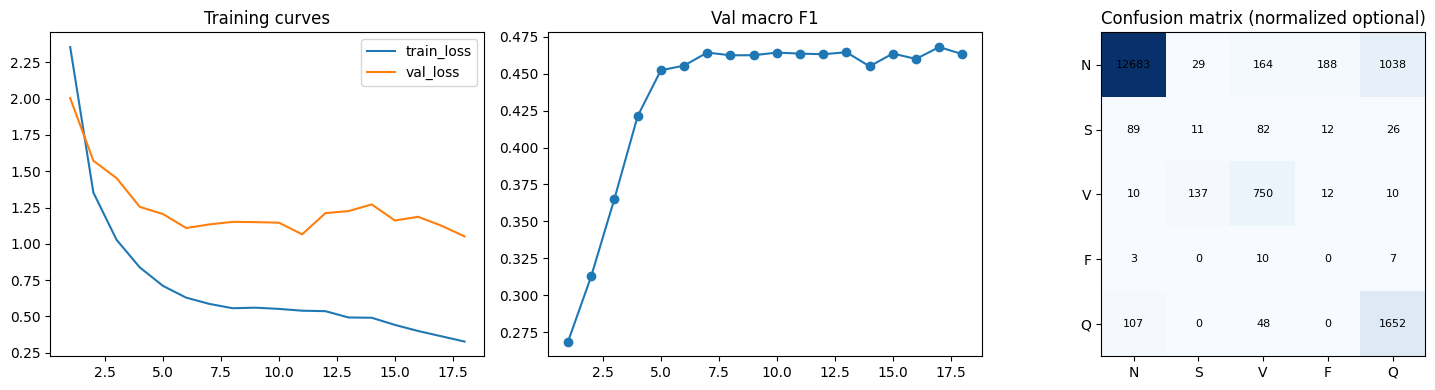

Saved: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/results/baseline/baseline_plots.png


In [9]:
hist = pd.DataFrame(history)
fig, axes = plt.subplots(1,3, figsize=(15,4))
axes[0].plot(hist['epoch'], hist['train_loss'], label='train_loss')
axes[0].plot(hist['epoch'], hist['val_loss'], label='val_loss')
axes[0].legend(); axes[0].set_title('Training curves')
axes[1].plot(hist['epoch'], hist['val_macro_f1'], marker='o')
axes[1].set_title('Val macro F1')
im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_title('Confusion matrix (normalized optional)')
axes[2].set_xticks(range(5)); axes[2].set_yticks(range(5))
axes[2].set_xticklabels(LABELS); axes[2].set_yticklabels(LABELS)
for i in range(5):
    for j in range(5):
        axes[2].text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=8)
plt.tight_layout()
plt.savefig(OUT / 'baseline_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', OUT / 'baseline_plots.png')